# Autoencoder for Cassini CDA Mass Spectra

This notebook implements a deep learning pipeline to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why this approach?
Scientific spacecraft data is often high-dimensional, sparse, and noisy. Standard clustering algorithms (like K-Means) often fail on raw raw data because they struggle with the "curse of dimensionality" and cannot distinguish between important spectral peaks and random instrument noise.

To solve this, we use a **Deep Convolutional Autoencoder** to learn a compressed, noise-free representation ("latent space") of the data before clustering.

### Pipeline Steps & Rationale:

1.  **Data Loading**: Load Parquet files containing the spectra.
2.  **Preprocessing**:
    *   **Log Transformation**: Mass spectra often have peaks that vary by orders of magnitude. A log transform $x' = \log(1+x)$ compresses this dynamic range so large peaks don't drown out smaller, significant features.
    *   **Normalization**: Neural networks train faster and more stably when inputs are scaled to a fixed range (0 to 1).
    *   **Binning (Resampling)**: Spacecraft data often has varying vector lengths or jitter. Binning to a fixed length (e.g., 1000 bins) ensures every input has the same dimensions for the Convolutional Neural Network (CNN).
3.  **Model (1D CNN Autoencoder)**:
    *   **Why 1D CNN?** Mass spectra are sequential data similar to audio or time-series. 1D Convolutions are excellent at detecting local patterns (like peak shapes) regardless of where they appear on the mass scale (shift invariance).
    *   **Why Autoencoder?** It forces the model to learn the most important underlying features to reconstruct the original signal, effectively filtering out random noise which is "hard to compress."
4.  **Clustering**: We apply K-Means on the learned **Latent Space** rather than the raw data. This groups spectra based on their structural content (chemical composition) rather than just pixel-by-pixel similarity.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt

# Configuration
Input_Length = 1000  # Number of bins to resample spectra to
Batch_Size = 32
Learning_Rate = 1e-3
Epochs = 20

print("Libraries loaded.")

Libraries loaded.


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly. We also filter or crop the data to ensure we are only training on valid signals.

In [3]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_train_pre2008277_lvl1.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded data shape: {df.shape}")
    print(df.head())
    
    # Extract spectral data
    # Based on the output, the column is named 'spectrum'
    if 'spectrum' in df.columns:
        print("Found 'spectrum' column.")
        # Ensure it's a stack of numpy arrays
        spectra_raw = np.stack(df['spectrum'].values)
    else:
        raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

Loaded data shape: (19817, 6)
         sclk   f_desc  event_id  \
0  1477581673  6405615      4035   
1  1477618778  6405615      6860   
2  1477626137  6405615     10363   
3  1477630001  6405615     12290   
4  1477665653  6405615     16489   

                                            spectrum       qi_ampl  class  
0  [8.7329244e-07, 1.2226094e-06, 8.7329244e-07, ...  5.004700e-14  Noise  
1  [1.047951e-06, 1.7465848e-07, 5.239755e-07, 1....  4.182420e-14  3-Car  
2  [1.3972679e-06, 5.239755e-07, 3.4931696e-07, 1...  1.700580e-14  3-Car  
3  [0.0, 8.7329244e-07, 3.4931696e-07, 3.4931696e...  1.312510e-14  3-KNa  
4  [0.0, -1.7465848e-07, 1.7465848e-07, 5.239755e...  4.949150e-12  Noise  
Found 'spectrum' column.


### 1.1 Class Analysis
Before training, it is crucial to understand the class imbalance. Real-world space data is dominated by "Noise" or empty impacts. Knowing the distribution helps us interpret why the model might cluster certain things together (e.g., if 90% of data is noise, the model will prioritize learning the shape of noise).

Class distribution:
class
Noise    12077
1         4491
2         1015
3          906
?          558
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
Name: count, dtype: int64

Total number of classes: 14


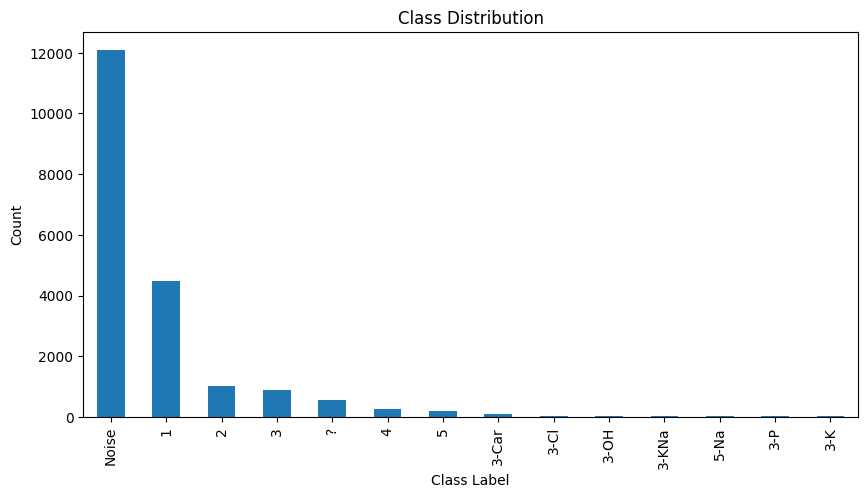

In [25]:
# 1.1 Analyze Classes
if 'class' in df.columns:
    print("Class distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
    print(f"\nTotal number of classes: {len(class_counts)}")
    
    # Optional: Plot class distribution
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.xlabel("Class Label")
    plt.show()
else:
    print("Column 'class' not found in dataframe.")

### 2. Preprocessing
We define a function to normalize and reshape the spectra.
*   **Target Length:** 1000 bins. This reduces the input dimensionality while preserving the resolution needed to distinguish mass lines.
*   **Log1p:** $\log(1+x)$ is used to squash the counts. Without this, a single giant peak (e.g., Amplitude 10,000) would render a small but chemically significant peak (Amplitude 10) invisible to the network (it would look like 0.001 after normalization).

In [26]:
# 2. Preprocessing Function
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths (if raw data is list of arrays)
        # Resize or pad/crop to target_length
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Log Transformation (Compress dynamic range)
        # Adding a small epsilon or 1 to avoid log(0) or log(negative) issues if any
        # Assuming minimal value is 0 or -small noise
        s = np.log1p(np.maximum(s, 0))
        
        # C. Max Normalization (Scale to 0-1 range)
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)

print(f"Processed Data Shape: {X_train.shape}")

# Convert to PyTorch Tensor
# Add channel dimension: (N, Channels, Length) -> (N, 1, 1000)
dataset = TensorDataset(torch.from_numpy(X_train).unsqueeze(1)) 
loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
print("DataLoader created.")

Preprocessing data...
Processed Data Shape: (19817, 1000)
DataLoader created.


### 3. Deep Convolutional Autoencoder Architecture
We construct a symmetric **Encoder-Decoder** network.
*   **Encoder**: Compresses the 1000-dimensional spectrum into a small "Latent Vector" (e.g., 64 or 128 features). It uses `Conv1d` layers to detect shapes and `ReLU` activations for non-linearity.
*   **Decoder**: Takes the latent vector and attempts to recreate the original 1000-dimensional spectrum using `ConvTranspose1d` (upsampling).
*   **Loss Function (MSE)**: The network is trained to minimize the Mean Squared Error between the Input and the Output. To minimize this error, it *must* learn to capture the peaks and ignore the random noise.

In [27]:
# 3. 1D Convolutional Autoencoder Model
class CDA_Autoencoder(nn.Module):
    def __init__(self, input_len=1000):
        super(CDA_Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=2, padding=1),  # L -> L/2
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1), # L/2 -> L/4
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3), # L/4 -> L/8
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.ConvTranspose1d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Output between 0 and 1
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CDA_Autoencoder(input_len=Input_Length).to(device)
print(model)

CDA_Autoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_paddi

### 4. Training the Model
We train the model using:
*   **Adam Optimizer**: An adaptive learning rate algorithm that is standard for deep learning.
*   **MSE Loss**: We measure the reconstruction quality.
*   **Batch Size**: We process 32 spectra at a time to average the gradients and stabilize learning.

In [28]:
# 4. Training Loop
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)

print("Starting training...")
for epoch in range(Epochs):
    total_loss = 0
    for batch in loader:
        img = batch[0].to(device)
        
        optimizer.zero_grad()
        recon, latent = model(img)
        loss = criterion(recon, img)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Print average loss per batch
    print(f"Epoch {epoch+1}/{Epochs}, Loss: {total_loss/len(loader):.6f}")

print("Training complete.")

Starting training...
Epoch 1/20, Loss: 0.020090
Epoch 2/20, Loss: 0.001513
Epoch 3/20, Loss: 0.001161
Epoch 4/20, Loss: 0.000757
Epoch 5/20, Loss: 0.000504
Epoch 6/20, Loss: 0.000571
Epoch 7/20, Loss: 0.000368
Epoch 8/20, Loss: 0.000332
Epoch 9/20, Loss: 0.000283
Epoch 10/20, Loss: 0.000234
Epoch 11/20, Loss: 0.000247
Epoch 12/20, Loss: 0.000173
Epoch 13/20, Loss: 0.000141
Epoch 14/20, Loss: 0.000114
Epoch 15/20, Loss: 0.000114
Epoch 16/20, Loss: 0.000103
Epoch 17/20, Loss: 0.000087
Epoch 18/20, Loss: 0.000087
Epoch 19/20, Loss: 0.000125
Epoch 20/20, Loss: 0.000072
Training complete.


### 4. Clustering & Analysis
Once trained, we use the **Encoder** to extract the "Latent Features" for every spectrum.
*   **Dimensionality Reduction**: We effectively reduced the data from 1000 dimensions (raw bins) to a small dense vector that describes the *chemistry* of the particle.
*   **K-Means**: We cluster these dense vectors to find natural groupings.
*   **Reconstruction Error**: We also calculate how well the model reconstructed each spectrum. High error usually usually indicates complex, rare signals (anomalies) or data artifacts, while low error indicates common signals (like simple Water Ice or Noise).

Clustering with KMeans (k=14)...

--- Cross-tabulation: Ground Truth (Rows) vs Unsupervised Clusters (Cols) ---
cluster_id   0    1    2    3    4     5     6     7     8     9    10    11  \
class                                                                          
1           646  438  192   17  391    47   127    26  1341     0    5  1247   
2            14    3  363   18  103    13     7     5    20     0    1   183   
3             8   26  210   25   32    52    78    40    94    11    4   234   
3-Car         0    0   51    0    0     0     0     0     0     0    0    10   
3-Cl          0    0   25    0    0     0     0     0     0     0    0     7   
3-K           0    0    7    0    0     1     0     0     0     0    0    14   
3-KNa         1    0   21    0    1     0     0     0     1     0    0     7   
3-OH          0    0   15    0    0     0     0     0     0     0    0    13   
3-P           0    0   15    0    0     0     0     0     0     0    0    18   
4       

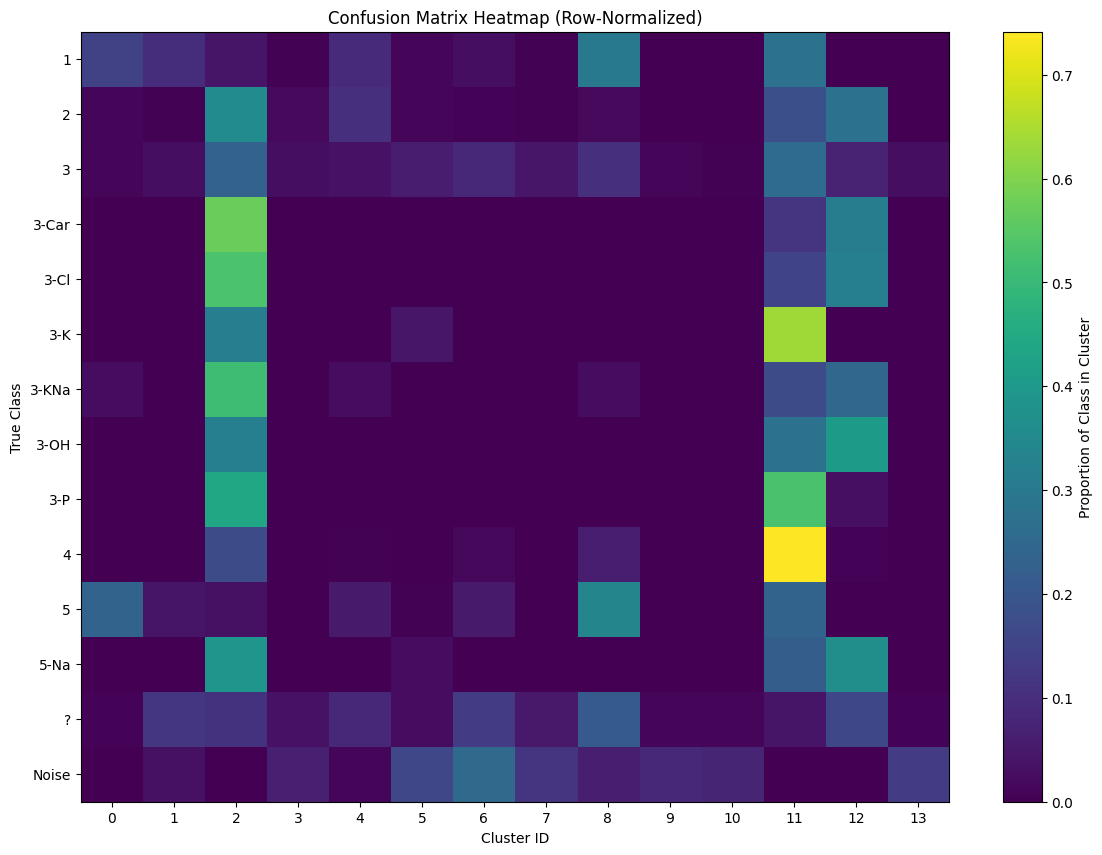


--- Reconstruction Error Analysis (Signal vs Noise) ---


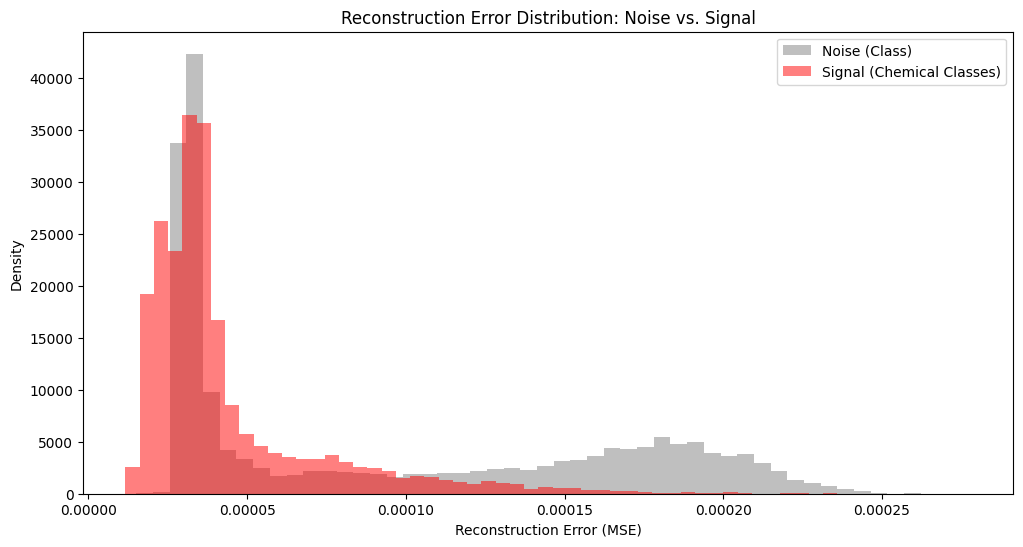

Mean Error (Noise):  0.000094
Mean Error (Signal): 0.000044


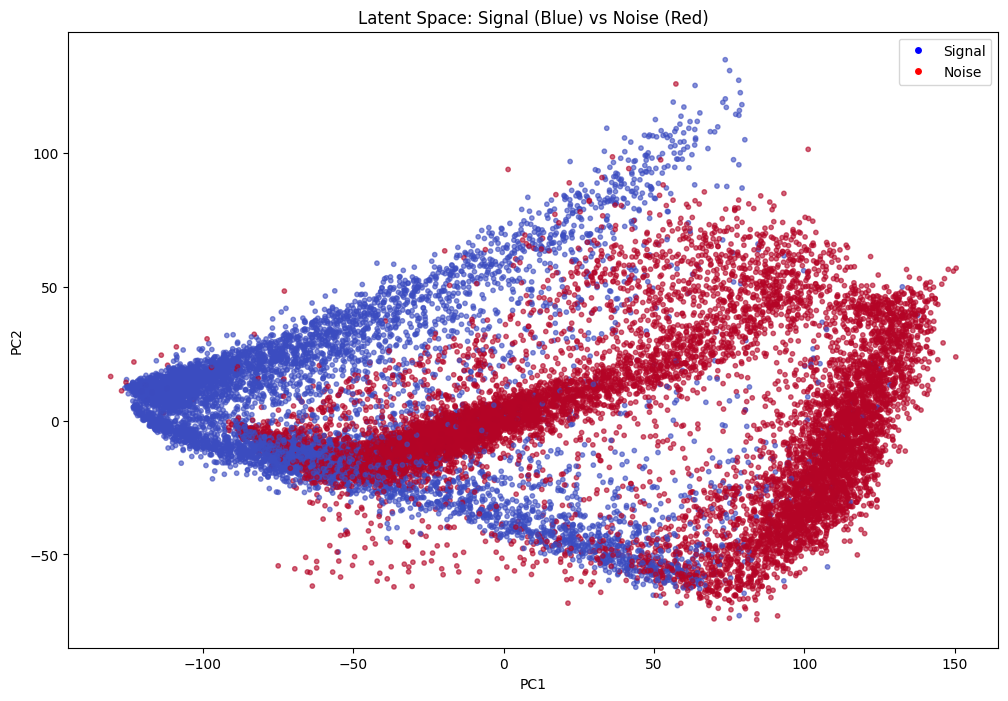

In [31]:
# 5. Extract Latent Space & Cluster
model.eval()
with torch.no_grad():
   # Pass all data through model in original order
   data_tensor = torch.from_numpy(X_train).unsqueeze(1).to(device)
   reconstructed, latent_features = model(data_tensor)
   
   # Flatten latent features: (N, Features)
   latent_flat = latent_features.view(latent_features.size(0), -1).cpu().numpy()
   
   # Calculate Reconstruction Error per sample (Anomaly Detection)
   # MSE between input (data_tensor) and output (reconstructed)
   # Shape: (N, 1, L) -> (N,)
   reconstruction_error = torch.mean((data_tensor - reconstructed) ** 2, dim=[1, 2]).cpu().numpy()

# 1. Clustering with KMeans
# Update n_clusters to match the number of ground truth classes (14)
n_clusters = 14
print(f"Clustering with KMeans (k={n_clusters})...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(latent_flat)

# Assign metrics back to dataframe
df['cluster_id'] = clusters
df['recon_error'] = reconstruction_error

# --- VALIDATION: Compare Clusters to Ground Truth ---
print("\n--- Cross-tabulation: Ground Truth (Rows) vs Unsupervised Clusters (Cols) ---")
crosstab = pd.crosstab(df['class'], df['cluster_id'])
print(crosstab)

# Heatmap Visualization of Confusion Matrix
plt.figure(figsize=(14, 10))
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)
plt.imshow(crosstab_norm, aspect='auto', cmap='viridis')
plt.colorbar(label='Proportion of Class in Cluster')
plt.title(f"Confusion Matrix Heatmap (Row-Normalized)")
plt.ylabel("True Class")
plt.xlabel("Cluster ID")
plt.xticks(range(len(crosstab.columns)), crosstab.columns)
plt.yticks(range(len(crosstab.index)), crosstab.index)
plt.show()

# --- NEW: Reconstruction Error Analysis ---
print("\n--- Reconstruction Error Analysis (Signal vs Noise) ---")
# Creates two groups: "Noise" and "Everything Else"
is_noise = df['class'] == 'Noise'
noise_errors = df[is_noise]['recon_error']
signal_errors = df[~is_noise]['recon_error']

plt.figure(figsize=(12, 6))
# Using log scale for x-axis if errors span orders of magnitude
plt.hist(noise_errors, bins=50, alpha=0.5, label='Noise (Class)', density=True, color='gray')
plt.hist(signal_errors, bins=50, alpha=0.5, label='Signal (Chemical Classes)', density=True, color='red')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution: Noise vs. Signal")
plt.legend()
plt.show()

# Print statistics
print(f"Mean Error (Noise):  {noise_errors.mean():.6f}")
print(f"Mean Error (Signal): {signal_errors.mean():.6f}")

# --- PCA Visualization ---
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(latent_flat)

plt.figure(figsize=(12, 8))
# Plots points, coloring by whether they are ground-truth noise or signal 
# to see if the autoencoder separates them structurally
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=is_noise, cmap='coolwarm', s=10, alpha=0.6)
plt.title(f"Latent Space: Signal (Blue) vs Noise (Red)")
plt.xlabel("PC1")
plt.ylabel("PC2")
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Signal'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Noise')]
plt.legend(handles=legend_elements)
plt.show()

### 6. Conclusion

In this experiment, we applied a Convolutional Autoencoder followed by K-Means clustering to Cassini mass spectra.

**Observations:**
1.  **Noise Dominance:** The dataset is heavily imbalanced, with the "Noise" class constituting the vast majority of samples.
2.  **Latent Space Occupancy:** Due to this imbalance, the Autoencoder's latent space is primarily organized around representing the noise features, as minimizing the reconstruction error for the majority class yields the lowest overall loss.
3.  **Signal vs. Noise Separation:** The model successfully learned to distinguish **Valid Signal** from **Noise**. The "Noise" class forms distinct clusters separate from the chemical signals.
4.  **Limitations on Chemical Classification:** While the model separated Signal from Noise, it struggled to distinguish between the specific valid chemical classes (e.g., Water Ice vs. Silicates). These classes were often merged into a single "Signal" cluster or confused. This suggests that the unsupervised autoencoder treats all "peaky" spectra as structurally similar compared to the flat noise, and does not naturally learn the subtle feature differences required for fine-grained chemical classification without supervision.